In [ ]:
import pandas as pd
import numbers as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r"C:\Users\kumar\Downloads\archive (9)\Social_Network_Ads.csv")

## logistic regression

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [ ]:
#df["Gender"]=df["Gender"].apply(lambda x:1 if x=="Male" else 0)

In [ ]:
df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [ ]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB
from sklearn.metrics import confusion_matrix,recall_score,f1_score,precision_score


In [ ]:
x=df[["Age","EstimatedSalary"]]
y=df["Purchased"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [ ]:
lg=LogisticRegression()
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
lg.score(x_test,y_test),lg.score(x_train,y_train)

(0.8875, 0.8375)

In [ ]:
x_test,y_test

(     Age  EstimatedSalary
 209   46            22000
 280   59            88000
 33    28            44000
 210   48            96000
 93    29            28000
 ..   ...              ...
 246   35            50000
 227   56           133000
 369   54            26000
 176   35            47000
 289   37            78000
 
 [80 rows x 2 columns],
 209    0
 280    1
 33     0
 210    1
 93     0
       ..
 246    0
 227    1
 369    1
 176    0
 289    1
 Name: Purchased, Length: 80, dtype: int64)

In [ ]:
lg.predict([[35,47000]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
from mlxtend.plotting import plot_decision_regions

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


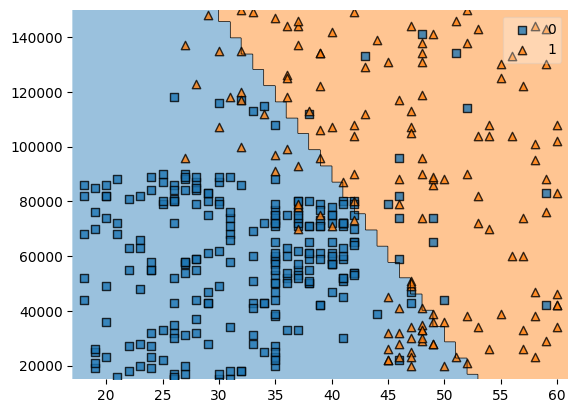

In [ ]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=lg)
plt.show()

In [ ]:
y_pre=lg.predict(x_test)
cd=confusion_matrix(y_test,y_pre)


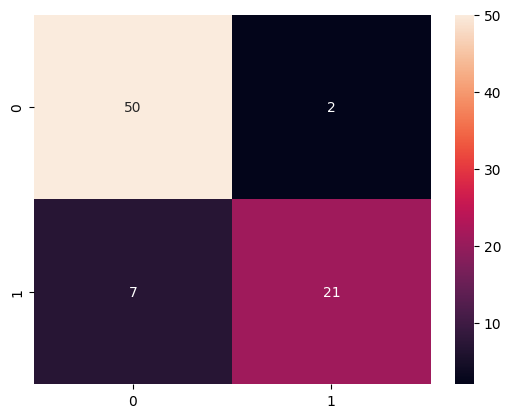

In [ ]:
sns.heatmap(cd,annot=True)
plt.show()

# Naive Bayes

In [ ]:
gs=GaussianNB()
gs.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [ ]:
gs.score(x_test,y_test),gs.score(x_train,y_train)

(0.925, 0.8625)

In [ ]:
gs.predict([[35,47000]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([0])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


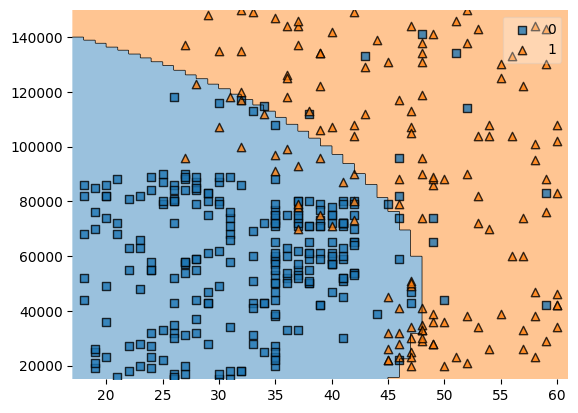

In [ ]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=gs)
plt.show()

In [ ]:
y_pre=gs.predict(x_test)
cm=confusion_matrix(y_test,y_pre)


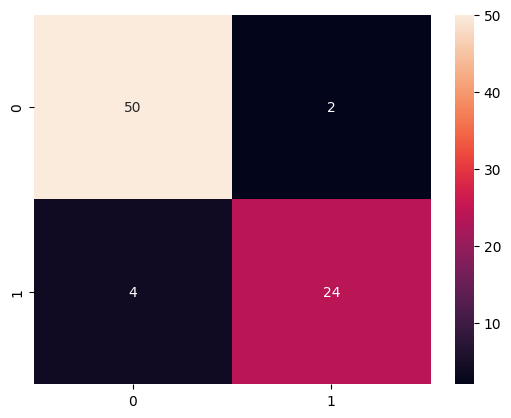

In [ ]:
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
br=BernoulliNB()

In [ ]:
br.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [ ]:
br.score(x_test,y_test),br.score(x_train,y_train)

(0.65, 0.640625)

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


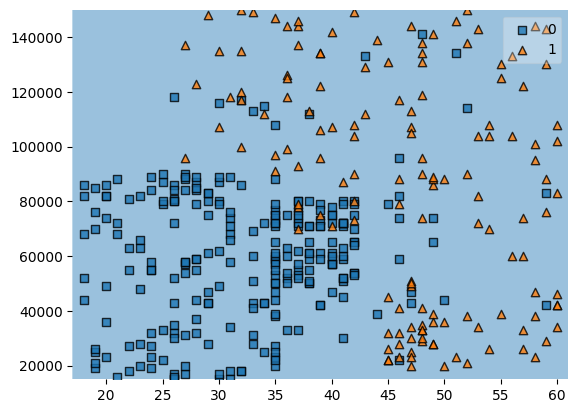

In [ ]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=br)
plt.show()

In [ ]:
ml=MultinomialNB()
ml.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [ ]:
ml.score(x_test,y_test),ml.score(x_train,y_train)

(0.6, 0.653125)

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


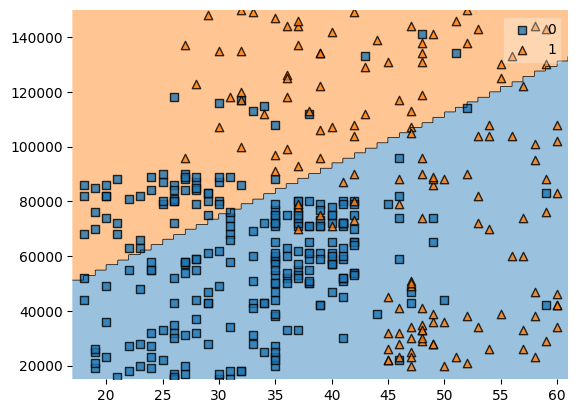

In [ ]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=ml)
plt.show()

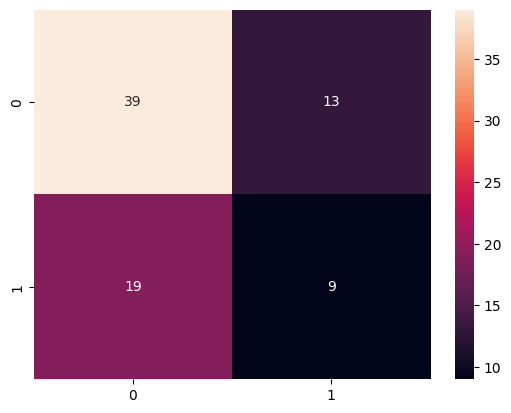

In [ ]:
cmm=confusion_matrix(y_test,ml.predict(x_test))
sns.heatmap(cmm,annot=True)
plt.show()

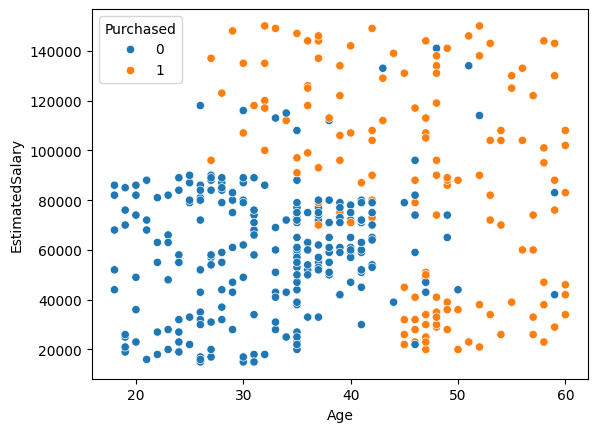

In [ ]:
sns.scatterplot(x="Age",y="EstimatedSalary",hue="Purchased",data=df)
plt.show()

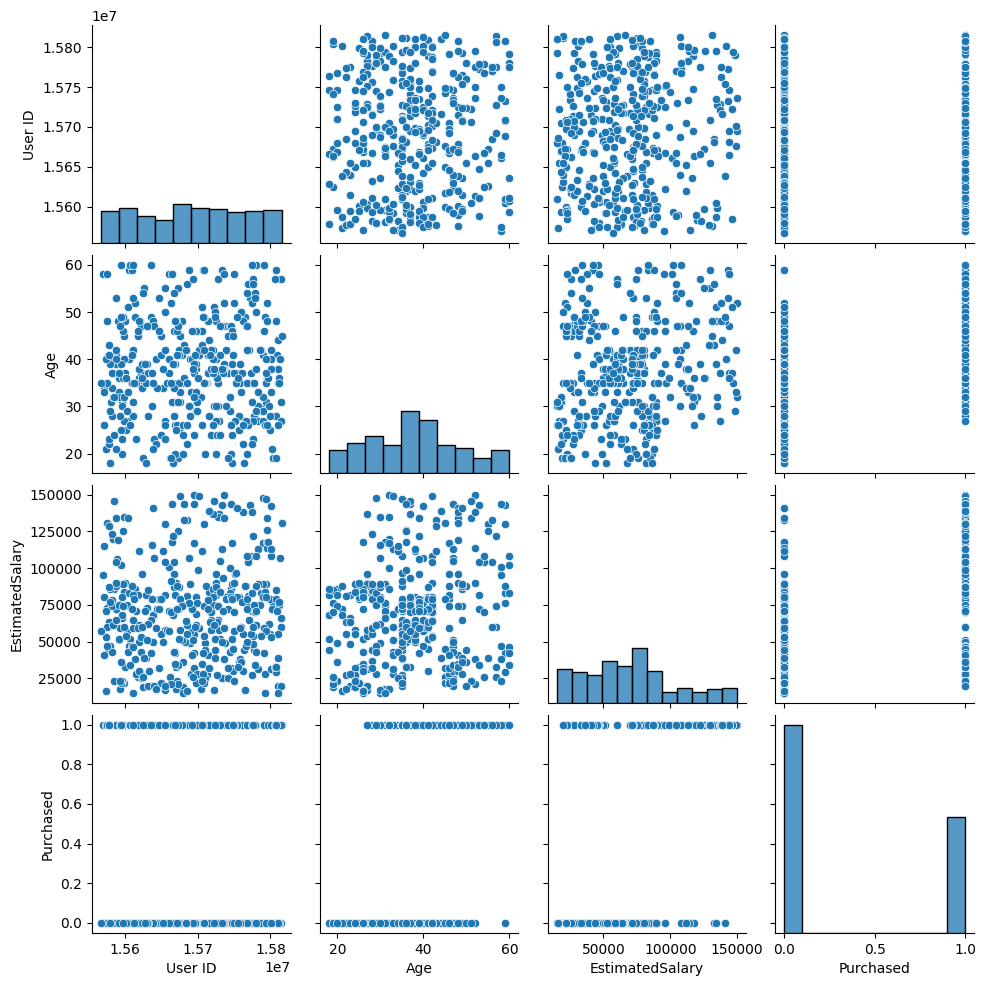

In [ ]:
sns.pairplot(data=df)
plt.show()

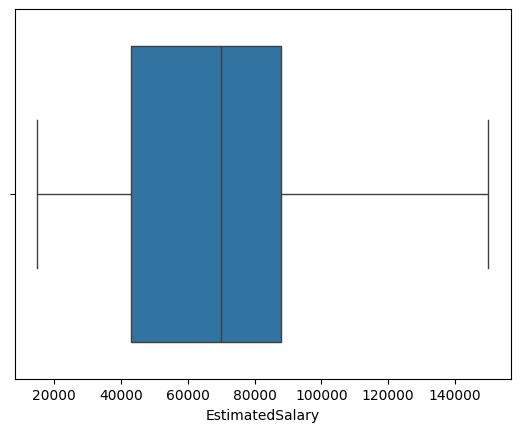

In [ ]:
sns.boxplot(x="EstimatedSalary",data=df)
plt.show()

C:\Users\kumar\AppData\Local\Temp\ipykernel_29532\2700528350.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df["EstimatedSalary"])


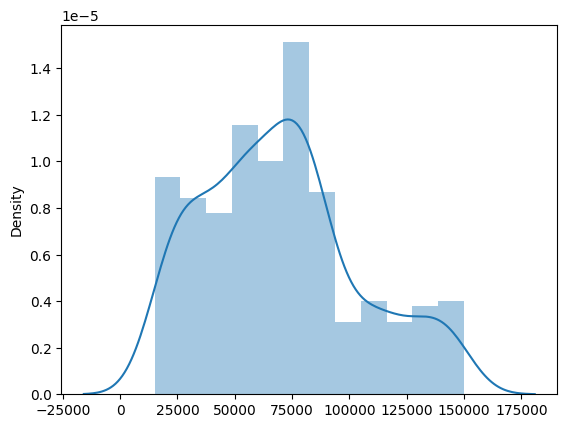

In [ ]:
sns.distplot(x=df["EstimatedSalary"])
plt.show()

In [ ]:
x.columns

Index(['Age', 'EstimatedSalary'], dtype='object')

# Polynomial Feature

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
pf=PolynomialFeatures(degree=2,include_bias=True)

In [ ]:

X=pd.DataFrame(pf.fit_transform(x))

In [ ]:
Y=y

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
lg.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
x_test,y_test

(     Age  EstimatedSalary
 209   46            22000
 280   59            88000
 33    28            44000
 210   48            96000
 93    29            28000
 ..   ...              ...
 246   35            50000
 227   56           133000
 369   54            26000
 176   35            47000
 289   37            78000
 
 [80 rows x 2 columns],
 209    0
 280    1
 33     0
 210    1
 93     0
       ..
 246    0
 227    1
 369    1
 176    0
 289    1
 Name: Purchased, Length: 80, dtype: int64)

In [ ]:
lg.score(X_test,Y_test)

0.8625

In [ ]:
data1=[[56,133000]]
new_data=pf.transform(data1)
print(lg.predict(new_data))

[1]


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt=DecisionTreeClassifier(max_depth=3)

In [ ]:
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
dt.predict([[37,78000]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
from sklearn.tree import plot_tree

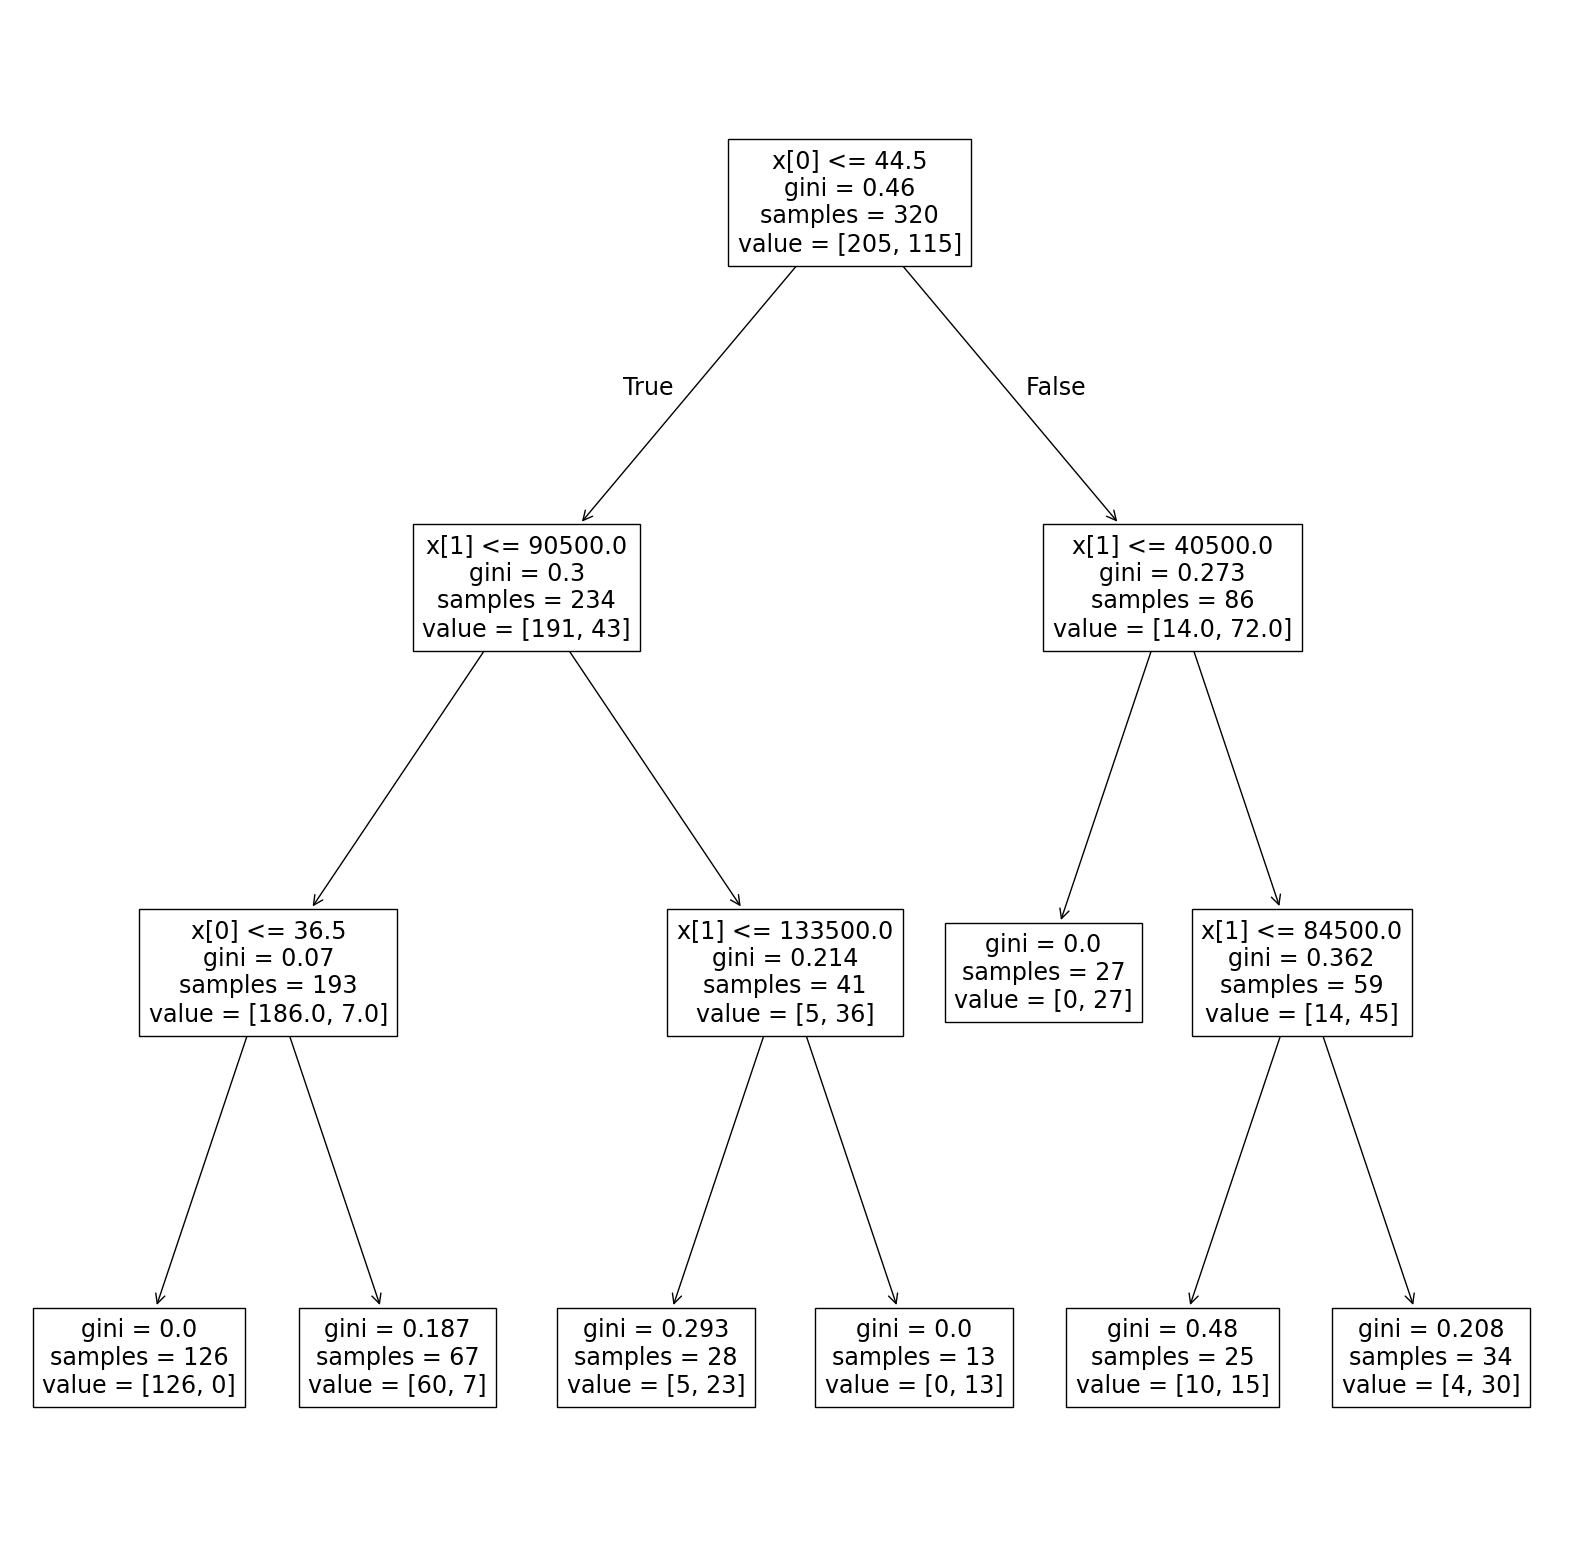

In [ ]:
plt.figure(figsize=(20,20))
plot_tree(dt)
plt.show()

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


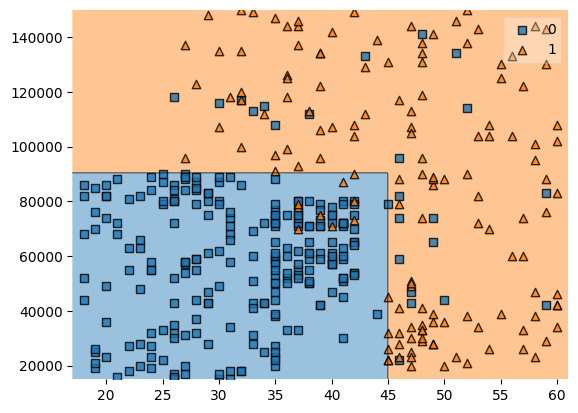

In [ ]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=dt)
plt.show()

In [ ]:
dt.score(x_test,y_test),dt.score(x_train,y_train)

(0.9125, 0.91875)

In [ ]:
for i in range(1,20):
    dt1=DecisionTreeClassifier(max_depth=i)
    dt1.fit(x_train,y_train)
    print(dt1.score(x_test,y_test)*100,  dt1.score(x_train,y_train)*100)

90.0 82.1875
91.25 91.875
91.25 91.875
91.25 93.125
90.0 93.4375
86.25 95.0
85.0 96.875
85.0 97.5
85.0 98.125
85.0 98.4375
83.75 99.0625
83.75 99.0625
83.75 99.6875
83.75 99.6875
83.75 99.6875
83.75 99.6875
83.75 99.6875
83.75 99.6875
83.75 99.6875


# KNN Algrothem

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
knn.score(x_test,y_test),knn.score(x_train,y_train)

(0.825, 0.88125)

In [ ]:
for i in range(1,30):
    knn1=KNeighborsClassifier(n_neighbors=i)
    knn1.fit(x_train,y_train)
    print(knn1.score(x_test,y_test)*100,  knn1.score(x_train,y_train)*100)

81.25 99.6875
76.25 87.8125
80.0 90.0
80.0 86.25
82.5 88.125
77.5 85.0
81.25 86.5625
77.5 85.0
80.0 85.0
77.5 83.125
80.0 84.375
77.5 82.5
75.0 82.8125
76.25 81.5625
77.5 82.8125
75.0 81.875
77.5 83.125
76.25 82.1875
76.25 82.8125
75.0 80.625
77.5 84.0625
76.25 81.875
76.25 82.8125
76.25 81.5625
77.5 82.1875
77.5 83.125
78.75 82.8125
78.75 81.5625
80.0 81.5625


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


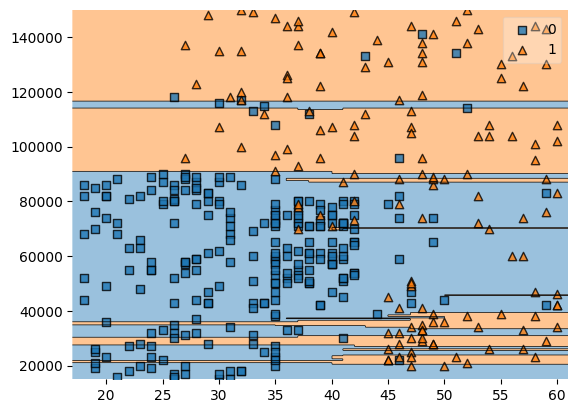

In [ ]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=knn)
plt.show()

# SVM

In [ ]:
from sklearn.svm import SVC
sv=SVC()